## Georg Seismic Experiment

Explore seismic signals at Bonn

## Imports

In [1]:
import os
import gc
import matplotlib.pyplot as plt
import numpy as np
import obspy as obs
import pandas as pd

from functions.spectra_class import spectra

from obspy.signal import PPSD

from andbro__read_sds import __read_sds
from andbro__trim_stream import __trim_stream

## Configurations

In [83]:
config = {}

# config['workdir'] = "/home/andbro/"
config['workdir'] = "/import/"

config['path_to_inv'] = config['workdir']+"kilauea-data/GEORG/stationxml/"

config['path_to_data'] = config['workdir']+"kilauea-data/GEORG/data/"

config['path_to_figs'] = config['workdir']+"kilauea-data/GEORG/figures/"

# config['tbeg'] = obs.UTCDateTime("2024-12-17 02:00")
# config['tend'] = obs.UTCDateTime("2024-12-17 04:00")


### Load Data

In [76]:
st_ring0 = obs.read(config['workdir']+"kilauea-data/GEORG/data/2024/XX/GEORG/BJZ.D/"+"XX.GEORG.10.BJZ.D.2024.361")

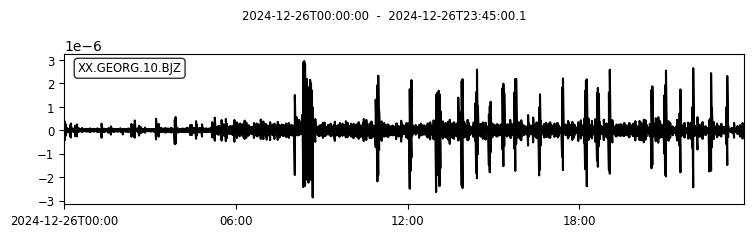

In [77]:
st_ring0.plot();

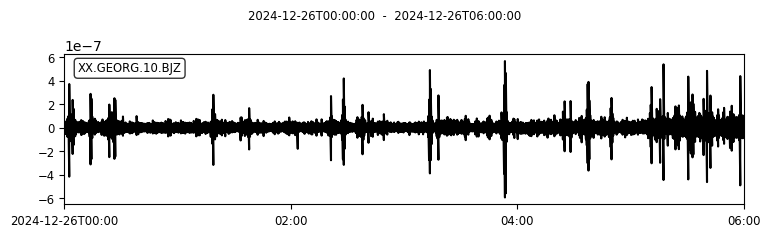

In [78]:
st_ring = st_ring0.trim(obs.UTCDateTime("2024-12-26 00:00"), obs.UTCDateTime("2024-12-26 06:00"))
st_ring.plot();

### Plot Spectra

/tmp/ipykernel_221478/3703861496.py:258: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(self.fmin, self.fmax)


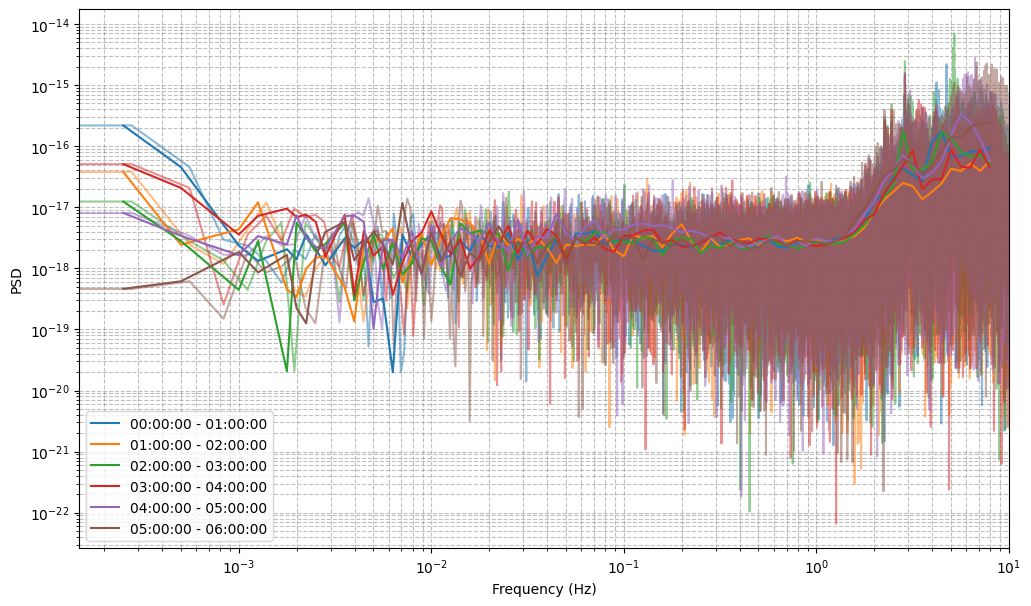

/tmp/ipykernel_221478/3703861496.py:327: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(self.fmin, self.fmax)


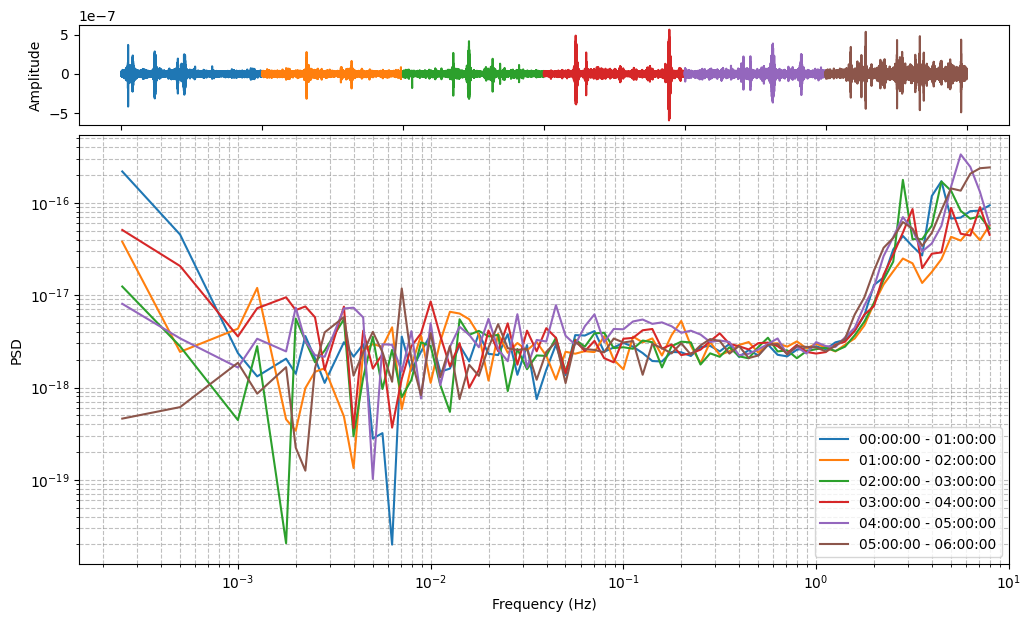

In [84]:
specs = spectra(st_ring[0], mode="psd")

specs.get_collection(tinterval=3600, toverlap=0, twin_sec=3600)

specs.get_fband_average(fraction_of_octave=6, average="mean")

specs.plot(mode="all")

fig = specs.plot_with_trace(mode="avg", out=True)

fig.savefig(config['path_to_figs']+"spectra_georg_BJZ.png", format="png", dpi=150, bbox_inches='tight')


In [109]:
st_ring = st_ring0.copy()

st_ring = st_ring.detrend("linear")
st_ring = st_ring.detrend("demean")
st_ring = st_ring.taper(0.05)
st_ring = st_ring.filter("bandpass", freqmin=0.01, freqmax=0.1, corners=4, zerophase=True)
# st_ring = st_ring.filter("lowpass", freq=0.1, corners=4, zerophase=True)

st_ring.plot();

## Plot Raw Data

In [70]:
st_ring0 = obs.read("/import/kilauea-data/GEORG/data/2024/XX/GEORG/FJZ.D/"+"XX.GEORG..FJZ.D.2024.361")

In [71]:
stx = st_ring0.trim(obs.UTCDateTime("2024-12-26 10:00"), obs.UTCDateTime("2024-12-26 15:00"))

/tmp/ipykernel_221478/3703861496.py:258: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(self.fmin, self.fmax)


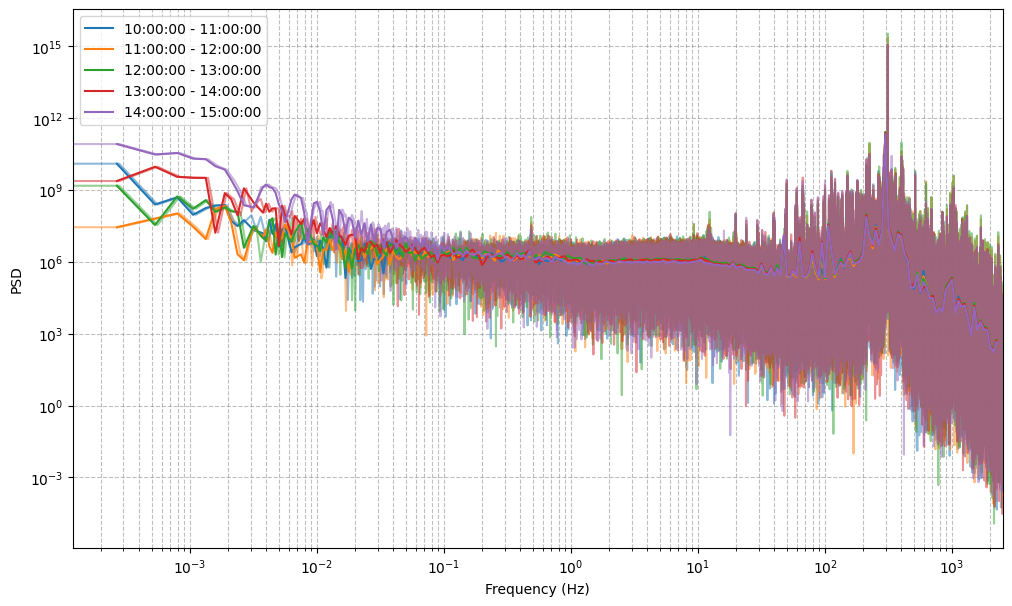

/tmp/ipykernel_221478/3703861496.py:327: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(self.fmin, self.fmax)


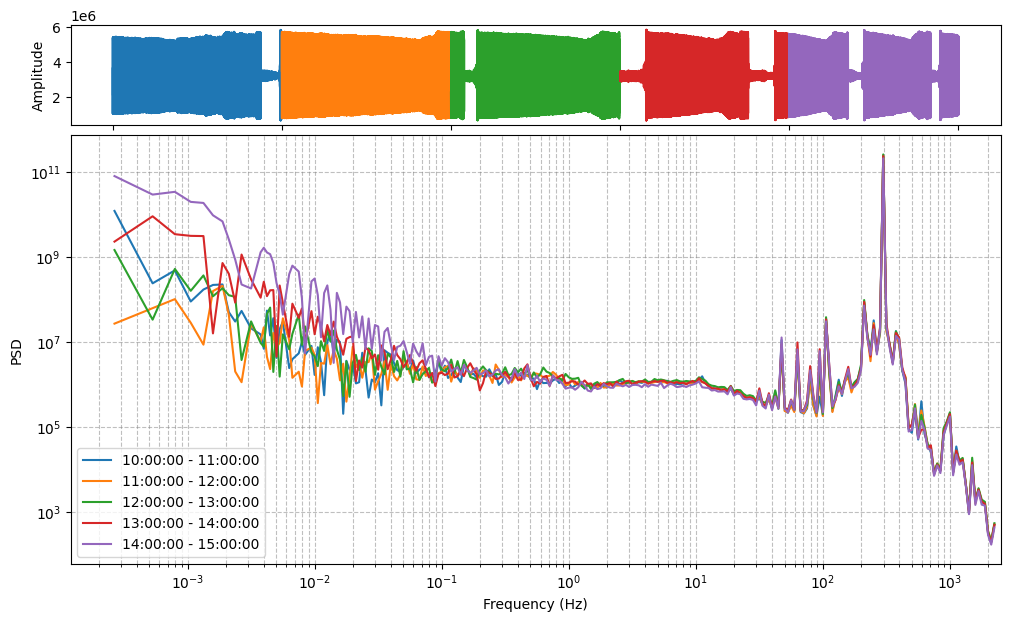

In [85]:
specs = spectra(stx[0], mode="psd")

specs.get_collection(tinterval=3600, toverlap=0, twin_sec=3600)

specs.get_fband_average(fraction_of_octave=12, average="mean")

specs.plot(mode="all")

fig = specs.plot_with_trace(mode="avg", out=True)

fig.savefig(config['path_to_figs']+"spectra_georg_FJZ.png", format="png", dpi=150, bbox_inches='tight')


In [32]:
72e-6*np.sin(np.deg2rad(50.72831))*4/632.8e-9

352.3326237232037

In [13]:
72e-6*np.sin(np.deg2rad(49.1448))*4/632.8e-9

344.2369994100643

In [50]:
class spectra:

    def __init__(self, trace, mode="fft"):

        self.tr = trace
        self.dt = trace.stats.delta

        self.tbeg = trace.stats.starttime
        self.tend = trace.stats.endtime

        self.mode = mode

    def get_time_intervals(self):
        '''
        Prepare time intervals
        '''

        from obspy import UTCDateTime

        times = []
        t1, t2 = self.tbeg, self.tbeg + self.t_interval

        while t2 <= self.tend:
            times.append((t1, t2))
            t1 = t1 + self.t_interval - self.t_overlap
            t2 = t2 + self.t_interval - self.t_overlap

        self.time_intervals = times

    def get_fft(self, arr, dt, window="hann"):
        '''
        Calculating a simple 1D FastFourierSpectrum of a time series.

        RETURN:

        frequencies, spectrum, phase

        >>> frequencies, spectrum, phase = __fft(signal_in, dt ,window=None,normalize=None)
        '''

        from scipy.fft import fft, fftfreq, fftshift
        from scipy import signal
        from numpy import angle, imag

        # determine length of the input time series
        n = int(len(arr))

        # calculate spectrum (with or without window function applied to time series)
        if window:
            win = signal.get_window(window, n);
            spectrum = fft(arr * win)

        else:
            spectrum = fft(arr)

        # calculate frequency array
        frequencies = fftfreq(n, d=dt)

        # correct amplitudes of spectrum
        magnitude = abs(spectrum) * 2.0 / n

        # compute phase spectrum
        phase = angle(spectrum, deg=False)

        # return the positive frequencies
        return magnitude[0:n//2], frequencies[0:n//2], phase[0:n//2]

    def get_welch_psd(self, arr, dt, twin_sec=60):
        '''
        Compute Welch power spectral density
        '''

        from scipy.signal import welch
        from scipy.signal.windows import hann

        nblock = int(1/dt * twin_sec)
        overlap = int(0.5*nblock)
        win = hann(nblock, True)

        ff, Pxx = welch(arr,
                        fs=1/dt,
                        window=win,
                        noverlap=overlap,
                        nfft=nblock,
                        scaling="density",
                        return_onesided=True,
                       )

        return ff, Pxx

    def get_collection(self, tinterval, toverlap, twin_sec=None):
        '''
        Get time intervals between starttime and endtime
        '''

        from gc import collect
        from numpy import nanmin, nanmax

        self.t_interval = tinterval
        self.t_overlap = toverlap

        self.get_time_intervals()

        out = {}
        out['freq'] = []
        out['spec'] = []
        out['phas'] = []
        out['time'] = []
        out['time_label'] = []

        for _t1, _t2 in self.time_intervals:

            _tr = self.tr.copy().trim(_t1, _t2)

            # compute FFT spectrum
            if self.mode == "fft":
                s, f, p = self.get_fft(_tr.data, _tr.stats.delta, window="hann")

            # compute psd with Welch method
            elif self.mode == "psd":
                if twin_sec is None:
                    f, s = self.get_welch_psd(_tr.data, _tr.stats.delta, twin_sec=tinterval)
                else:
                    f, s = self.get_welch_psd(_tr.data, _tr.stats.delta, twin_sec=twin_sec)

                # set dummy phases
                p = f * 0

            out['time_label'].append(f"{_tr.stats.starttime.time} - {_tr.stats.endtime.time}")
            out['freq'].append(f)
            out['spec'].append(s)
            out['phas'].append(p)
            out['time'].append(_tr.stats.starttime+0.5*(_tr.stats.endtime-_tr.stats.starttime))

            del _tr
            collect()

        self.fmin = nanmin(f)
        self.fmax = nanmax(f)
        self.collection = out

    def get_octave_bands(self, fmin, fmax, fraction_of_octave=1):
        '''
        Computing octave bands
        '''

        from acoustics.octave import Octave
        from numpy import array

        # avoid fmin = zero
        if fmin == 0:
            # print(f" -> set fmin to 1e-10 instead of 0")
            fmin = 1e-10

        f_lower, f_upper, f_centers = [], [], []

        _octaves = Octave(fraction=fraction_of_octave,
                          interval=None,
                          fmin=fmin,
                          fmax=fmax,
                          unique=False,
                          reference=1000.0
                         )

        f_centers = array(_octaves.center)
        f_lower = array(_octaves.lower)
        f_upper = array(_octaves.upper)

        return f_lower, f_upper, f_centers

    def get_fband_average(self, fraction_of_octave=1, average="mean"):
        '''
        Computing averages for frequency octave bands.
        '''

        import matplotlib.pyplot as plt
        from numpy import nanmean, nanmedian, array

        # get octave bands
        f_center, f_upper, f_lower = self.get_octave_bands(self.fmin,
                                                           self.fmax,
                                                           fraction_of_octave=fraction_of_octave,
                                                          )

        out = {}
        out['fcenter'] = []
        out['flower'] = []
        out['fupper'] = []
        out['specavg'] = []

        for freq, spec, in zip(self.collection['freq'], self.collection['spec']):

            # get frequency indices
            fl_idx, fu_idx = [], []

            for _k, (fl, fu) in enumerate(zip(f_lower, f_upper)):
                if _k <= len(f_center):

                    for _i, _f in enumerate(freq):
                        if _f >= fl:
                            fl_idx.append(int(_i))
                            break

                    for _i, _f in enumerate(freq):
                        if _f >= fu:
                            fu_idx.append(int(_i))
                            break

            ## compute mean per band
            psd_average, fc, fu, fl = [], [], [], []
            for _n, (ifl, ifu) in enumerate(zip(fl_idx, fu_idx)):
                if ifl != ifu:
                    if average == "mean":
                        psd_average.append(nanmean(spec[ifl:ifu]))
                    elif average == "median":
                        psd_average.append(nanmedian(spec[ifl:ifu]))

                    fc.append(f_center[_n])
                    fu.append(f_upper[_n])
                    fl.append(f_lower[_n])

            out['fcenter'].append(array(fc))
            out['fupper'].append(array(fu))
            out['flower'].append(array(fl))
            out['specavg'].append(array(psd_average))

            out['time_label'] = self.collection['time_label']
            out['time'] = self.collection['time']

        self.collection_avg = out

    def plot(self, mode=None, out=False):

        fig = plt.figure(figsize=(12, 7))

        if mode is None:
            for t, f, s in zip(self.collection['time_label'], self.collection['freq'], self.collection['spec']):
                plt.plot(f, s, label=t)

        elif mode == "avg":
            for t, f, s in zip(self.collection_avg['time_label'], self.collection_avg['fcenter'], self.collection_avg['specavg']):
                plt.plot(f, s, label=t)

        elif mode == "all":

            for t, f, s in zip(self.collection['time_label'], self.collection['freq'], self.collection['spec']):
                plt.plot(f, s, alpha=0.5)

            # reset color cycle
            plt.gca().set_prop_cycle(None)

            for t, f, s in zip(self.collection_avg['time_label'], self.collection_avg['fcenter'], self.collection_avg['specavg']):
                plt.plot(f, s, label=t)

        plt.yscale("log")
        plt.xscale("log")

        plt.xlim(self.fmin, self.fmax)

        plt.xlabel("Frequency (Hz)")

        if self.mode == "fft":
            plt.ylabel("Spectrum")
        elif self.mode == "psd":
            plt.ylabel("PSD")

        plt.legend()

        plt.grid(which="both", ls="--", color="grey", alpha=0.5, zorder=0)

        plt.show();
        if out:
            return fig

    def plot_with_trace(self, mode=None, out=False):

        import matplotlib.pyplot as plt
        import numpy as np
        from matplotlib.gridspec import GridSpec

        tscale, tunit = 1/3600, "hour"

        Ncol, Nrow = 1, 5

        font = 12

        fig = plt.figure(figsize=(12, 7))

        gs1 = GridSpec(Nrow, Ncol, figure=fig, hspace=0.1, wspace=0.2)

        ax1 = fig.add_subplot(gs1[0, :])
        ax2 = fig.add_subplot(gs1[1:, :])

        for n, (_t1, _t2) in enumerate(self.time_intervals):
            _tr = self.tr.copy().trim(_t1, _t2)
    
            _times = np.arange(0, _t2-_t1+_tr.stats.delta, _tr.stats.delta) + n * (_t2-_t1)

            ax1.plot(_times*tscale, _tr)

        ax1.set_ylabel("Amplitude")

            
        if mode is None:
            for t, f, s in zip(self.collection['time_label'], self.collection['freq'], self.collection['spec']):
                ax2.plot(f, s, label=t)

        elif mode == "avg":
            for t, f, s in zip(self.collection_avg['time_label'], self.collection_avg['fcenter'], self.collection_avg['specavg']):
                ax2.plot(f, s, label=t)

        elif mode == "all":

            for t, f, s in zip(self.collection['time_label'], self.collection['freq'], self.collection['spec']):
                ax2.plot(f, s, alpha=0.5)

            # reset color cycle
            plt.gca().set_prop_cycle(None)

            for t, f, s in zip(self.collection_avg['time_label'], self.collection_avg['fcenter'], self.collection_avg['specavg']):
                ax2.plot(f, s, label=t)

        ax2.grid(which="both", ls="--", color="grey", alpha=0.5, zorder=0)
        ax2.set_yscale("log")
        ax2.set_xscale("log")

        ax2.set_xlim(self.fmin, self.fmax)

        ax2.set_xlabel("Frequency (Hz)")

        if self.mode == "fft":
            ax2.set_ylabel("Spectrum")
        elif self.mode == "psd":
            ax2.set_ylabel("PSD")

        ax2.legend()

        plt.show();
        if out:
            return fig

In [60]:
ffts = spectra(stx[0], mode="psd")

In [61]:
ffts.get_collection(tinterval=3600, toverlap=0, twin_sec=3600)

/tmp/ipykernel_221478/3703861496.py:258: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(self.fmin, self.fmax)


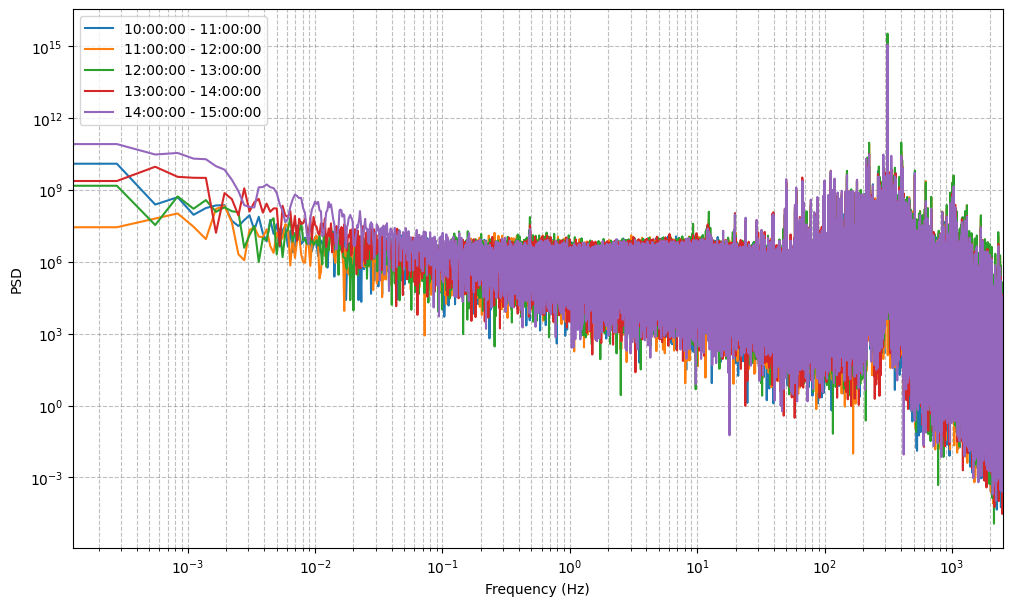

In [62]:
ffts.plot()

In [63]:
ffts.get_fband_average(fraction_of_octave=12, average="mean")

/tmp/ipykernel_221478/3703861496.py:258: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(self.fmin, self.fmax)


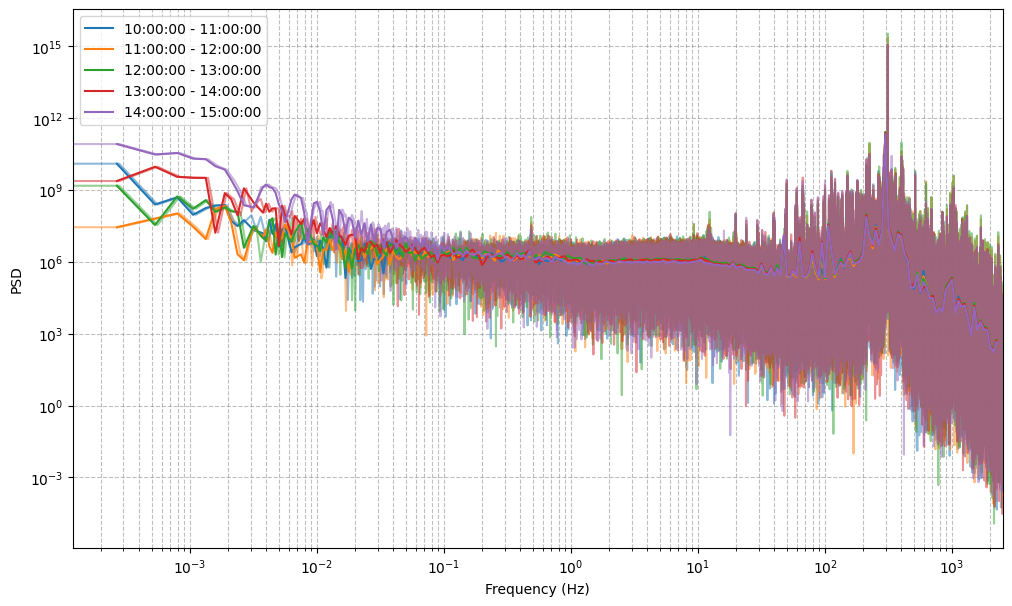

In [64]:
ffts.plot(mode="all")

/tmp/ipykernel_221478/3703861496.py:327: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(self.fmin, self.fmax)


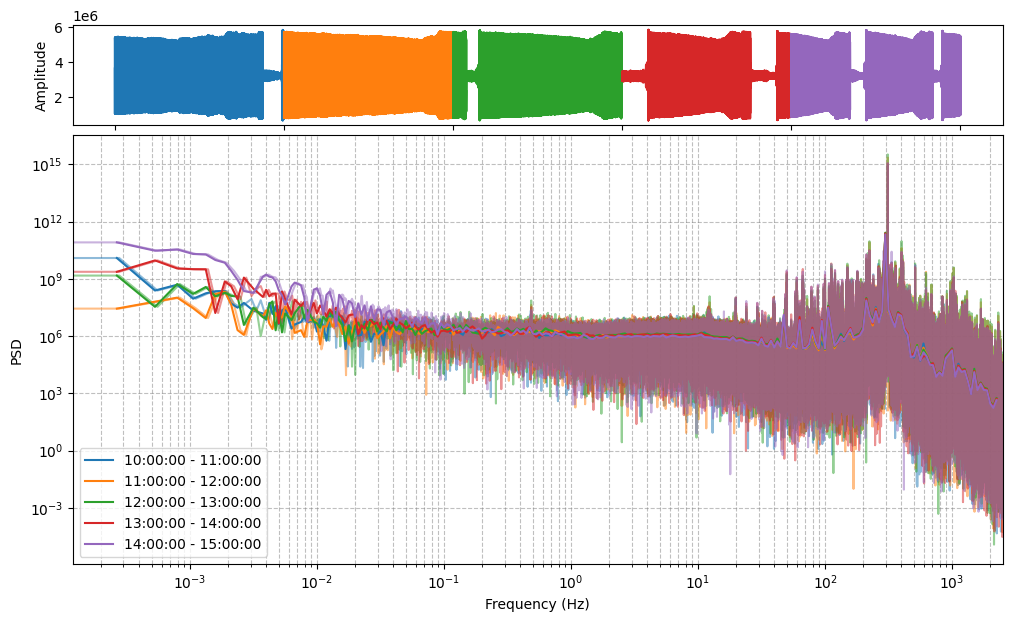

In [65]:
ffts.plot_with_trace(mode="all")